<a href="https://colab.research.google.com/github/rakshitarajan/ML-LAB-2/blob/main/Sequential_Covering_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 0 : THE ENJOYSPORT DATASET
         Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0      Sunny    Warm   Normal  Strong  Warm     Same        Yes
1      Sunny    Warm     High  Strong  Warm     Same        Yes
2      Sunny    Cold   Normal    Weak  Warm   Change        Yes
3      Sunny    Warm   Normal    Weak  Warm   Change        Yes
4      Sunny    Cold     High  Strong  Warm     Same        Yes
5      Sunny    Warm     High    Weak  Warm   Change        Yes
6      Rainy    Warm   Normal  Strong  Cool     Same        Yes
7   Overcast    Cold     High  Strong  Cool     Same        Yes
8      Sunny    Cold   Normal  Strong  Cool     Same        Yes
9      Rainy    Cold     High    Weak  Cool   Change         No
10  Overcast    Warm   Normal    Weak  Warm   Change         No
11     Rainy    Warm     High  Strong  Cool   Change         No
12  Overcast    Cold   Normal    Weak  Cool     Same         No
13     Sunny    Warm   Normal    Weak  Cool   Change         No

Total e

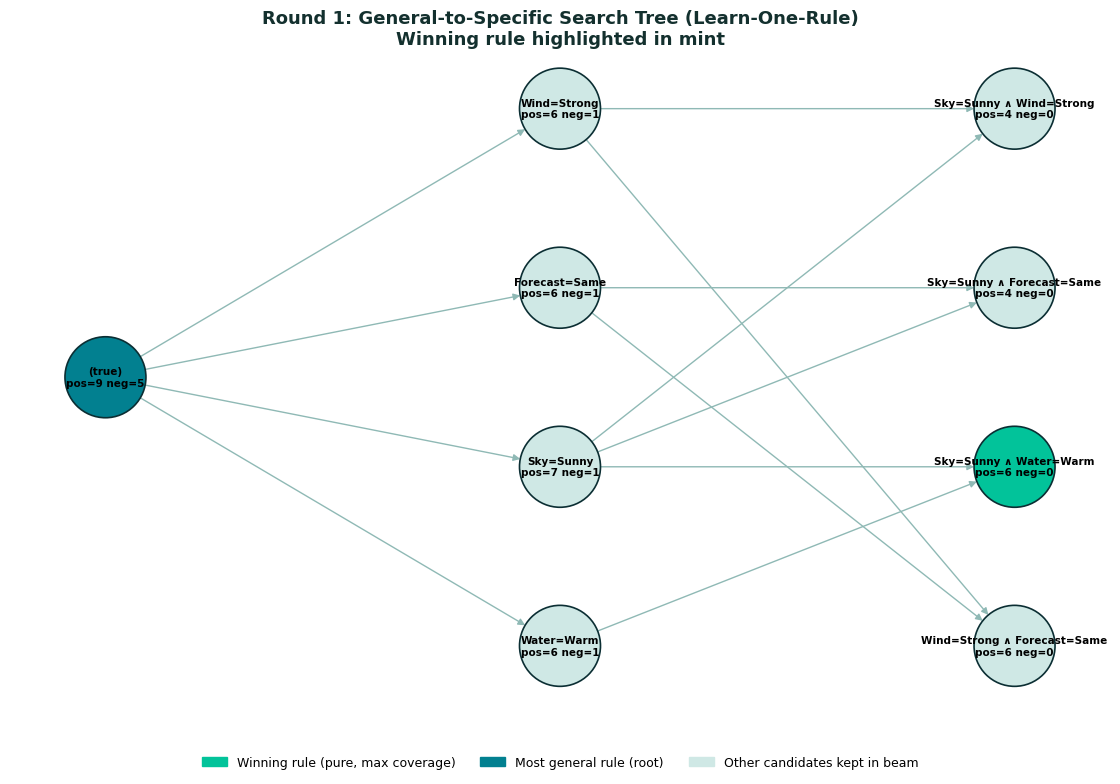

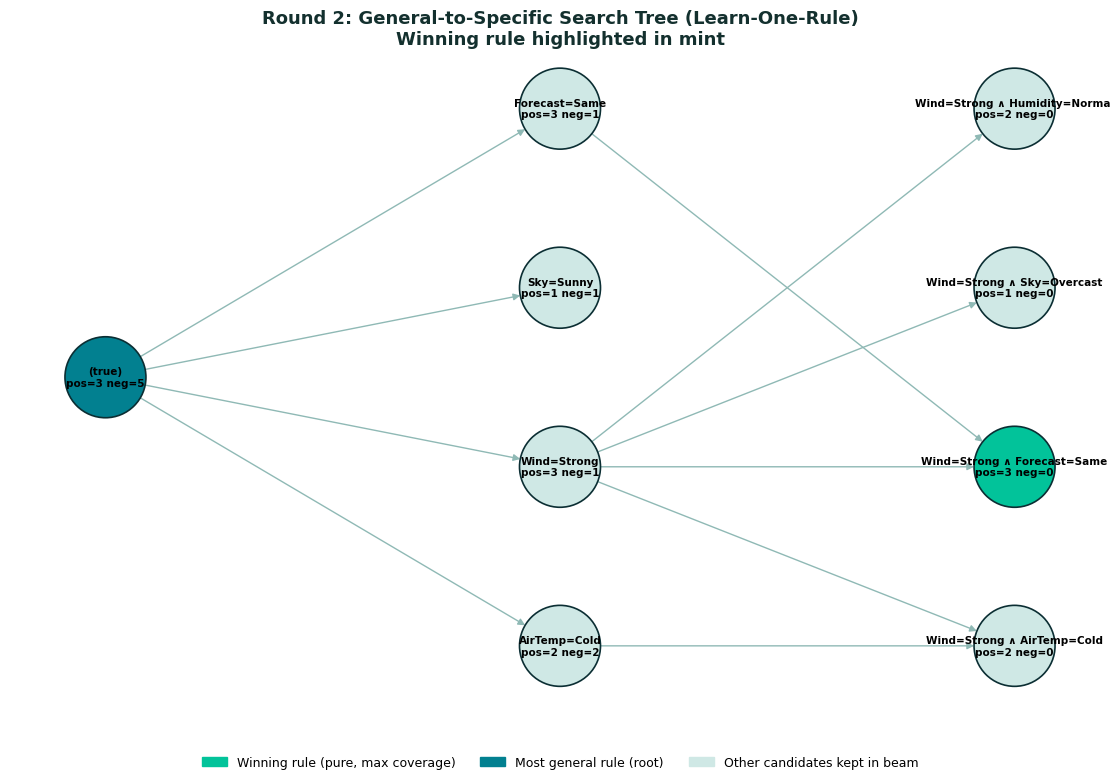

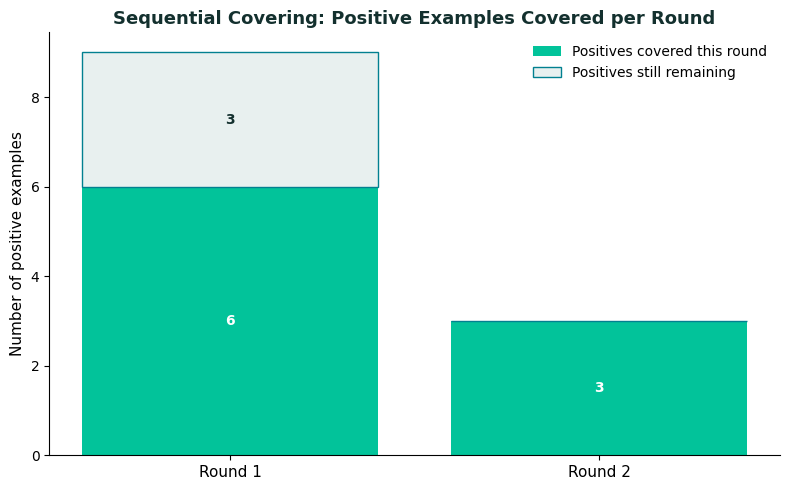

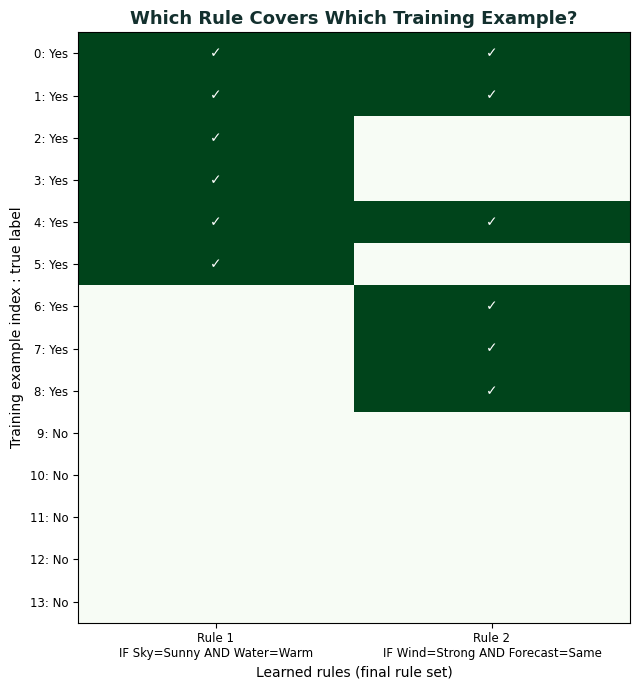

In [ ]:
"""
Sequential Covering Algorithm — Full Implementation with Visual Graphs
========================================================================
Module 2: Learning Sets of Rules | BCI702

Run this cell in Google Colab — it will:
  1. Print the EnjoySport dataset (14 examples, mixed positive/negative)
  2. Run LEARN-ONE-RULE (general-to-specific BEAM SEARCH)
  3. Run SEQUENTIAL-COVERING (repeat Learn-One-Rule, remove covered
     positives, repeat until all positives are explained)
  4. Display 4 graphs inline:
       - Search tree for each round (networkx) showing every candidate
         rule considered, colored by purity, winner highlighted
       - Bar chart of positive coverage per round
       - Heatmap of which final rule covers which training example
"""

!pip install networkx -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ------------------------------------------------------------------
# 1. THE DATASET  (EnjoySport — 14 examples, 9 positive / 5 negative)
# ------------------------------------------------------------------
# Built so that:
#   Rule 1  Sky=Sunny  AND  Water=Warm        -> covers 6 positives, 0 negatives
#   Rule 2  Wind=Strong AND Forecast=Same     -> covers remaining 3 positives, 0 negatives

columns = ["Sky", "AirTemp", "Humidity", "Wind", "Water", "Forecast", "EnjoySport"]

data = [
    # ---- positives covered by Rule 1: Sky=Sunny & Water=Warm ----
    ["Sunny",   "Warm", "Normal", "Strong", "Warm", "Same",   "Yes"],
    ["Sunny",   "Warm", "High",   "Strong", "Warm", "Same",   "Yes"],
    ["Sunny",   "Cold", "Normal", "Weak",   "Warm", "Change", "Yes"],
    ["Sunny",   "Warm", "Normal", "Weak",   "Warm", "Change", "Yes"],
    ["Sunny",   "Cold", "High",   "Strong", "Warm", "Same",   "Yes"],
    ["Sunny",   "Warm", "High",   "Weak",   "Warm", "Change", "Yes"],
    # ---- positives covered by Rule 2: Wind=Strong & Forecast=Same ----
    ["Rainy",    "Warm", "Normal", "Strong", "Cool", "Same",   "Yes"],
    ["Overcast", "Cold", "High",   "Strong", "Cool", "Same",   "Yes"],
    ["Sunny",    "Cold", "Normal", "Strong", "Cool", "Same",   "Yes"],
    # ---- negative examples (satisfy neither rule) ----
    ["Rainy",    "Cold", "High",   "Weak",   "Cool", "Change", "No"],
    ["Overcast", "Warm", "Normal", "Weak",   "Warm", "Change", "No"],
    ["Rainy",    "Warm", "High",   "Strong", "Cool", "Change", "No"],
    ["Overcast", "Cold", "Normal", "Weak",   "Cool", "Same",   "No"],
    ["Sunny",    "Warm", "Normal", "Weak",   "Cool", "Change", "No"],
]

df = pd.DataFrame(data, columns=columns)
TARGET_ATTR = "EnjoySport"
TARGET_VAL = "Yes"
ATTRIBUTES = [c for c in columns if c != TARGET_ATTR]

# Domain (possible values) of every attribute
DOMAIN = {attr: sorted(df[attr].unique()) for attr in ATTRIBUTES}

def print_dataset():
    print("=" * 78)
    print("STEP 0 : THE ENJOYSPORT DATASET")
    print("=" * 78)
    print(df.to_string(index=True))
    n_pos = (df[TARGET_ATTR] == TARGET_VAL).sum()
    n_neg = (df[TARGET_ATTR] != TARGET_VAL).sum()
    print(f"\nTotal examples: {len(df)}   |   Positive (Yes): {n_pos}   |   Negative (No): {n_neg}")
    print()

# ------------------------------------------------------------------
# 2. RULE REPRESENTATION & SCORING
# ------------------------------------------------------------------
# A rule/hypothesis is a dict {attribute: value, ...}. An empty dict {}
# is the MOST GENERAL rule (matches every example).

def covers(rule, row):
    """Does this example satisfy every condition in the rule?"""
    return all(row[attr] == val for attr, val in rule.items())

def evaluate(rule, examples):
    """Return (positives_covered, negatives_covered, precision)."""
    covered = examples[examples.apply(lambda r: covers(rule, r), axis=1)]
    pos = (covered[TARGET_ATTR] == TARGET_VAL).sum()
    neg = (covered[TARGET_ATTR] != TARGET_VAL).sum()
    precision = pos / (pos + neg) if (pos + neg) > 0 else 0.0
    return pos, neg, precision

def rule_to_str(rule):
    if not rule:
        return "IF (true)"
    conds = " AND ".join(f"{a}={v}" for a, v in rule.items())
    return f"IF {conds}"

# ------------------------------------------------------------------
# 3. LEARN-ONE-RULE  ->  General-to-Specific BEAM SEARCH
# ------------------------------------------------------------------
def learn_one_rule(examples, beam_width=4, max_conditions=None):
    """
    Performs a general-to-specific beam search starting from the empty
    (most general) rule, adding one attribute=value condition at a time.
    Returns: best_rule, best_pos, best_neg, best_prec, search_history
    """
    if max_conditions is None:
        max_conditions = len(ATTRIBUTES)

    search_history = []

    # depth 0 : the most general rule
    beam = [{}]
    depth0_pos, depth0_neg, depth0_prec = evaluate({}, examples)
    search_history.append({
        "depth": 0,
        "candidates": [({}, depth0_pos, depth0_neg, depth0_prec, None)],
        "beam": [{}],
    })

    best_rule, best_pos, best_neg, best_prec = {}, depth0_pos, depth0_neg, depth0_prec

    for depth in range(1, max_conditions + 1):
        candidates = []
        for parent in beam:
            used_attrs = set(parent.keys())
            for attr in ATTRIBUTES:
                if attr in used_attrs:
                    continue
                for val in DOMAIN[attr]:
                    child = dict(parent)
                    child[attr] = val
                    pos, neg, prec = evaluate(child, examples)
                    if pos == 0:
                        continue  # useless specialization, covers no positives
                    candidates.append((child, pos, neg, prec, parent))

        if not candidates:
            break

        # Rank candidates: purity first (neg == 0), then precision, then coverage
        candidates.sort(key=lambda c: (c[2] == 0, c[3], c[1]), reverse=True)

        # Keep top beam_width distinct hypotheses for the next round
        new_beam = []
        seen = set()
        for child, pos, neg, prec, parent in candidates:
            key = frozenset(child.items())
            if key not in seen:
                seen.add(key)
                new_beam.append(child)
            if len(new_beam) >= beam_width:
                break
        beam = new_beam

        search_history.append({"depth": depth, "candidates": candidates, "beam": beam})

        # Check: is there a PURE rule (0 negatives covered) in this depth's candidates?
        pure_candidates = [c for c in candidates if c[2] == 0]
        if pure_candidates:
            top = pure_candidates[0]
            best_rule, best_pos, best_neg, best_prec = top[0], top[1], top[2], top[3]
            break
        else:
            top = candidates[0]
            if (top[2] == 0, top[3], top[1]) > (best_neg == 0, best_prec, best_pos):
                best_rule, best_pos, best_neg, best_prec = top[0], top[1], top[2], top[3]

    return best_rule, best_pos, best_neg, best_prec, search_history

# ------------------------------------------------------------------
# 4. SEQUENTIAL COVERING
# ------------------------------------------------------------------
def sequential_covering(beam_width=4):
    working = df.copy()
    rules = []
    round_logs = []
    round_num = 1

    while (working[TARGET_ATTR] == TARGET_VAL).sum() > 0:
        rule, pos, neg, prec, history = learn_one_rule(working, beam_width=beam_width)

        covered_mask = working.apply(lambda r: covers(rule, r), axis=1)
        covered_examples = working[covered_mask]
        covered_positive_idx = covered_examples[covered_examples[TARGET_ATTR] == TARGET_VAL].index.tolist()

        print(f"--- Round {round_num} ---")
        print(f"Remaining positives before this round : {(working[TARGET_ATTR]==TARGET_VAL).sum()}")
        print(f"Learned rule                           : {rule_to_str(rule)}  THEN {TARGET_ATTR} = {TARGET_VAL}")
        print(f"Covers                                 : {pos} positive(s), {neg} negative(s)")
        print(f"Positive example indices covered       : {covered_positive_idx}")
        print()

        rules.append(rule)
        round_logs.append({
            "round": round_num, "rule": rule, "pos_covered": pos, "neg_covered": neg,
            "covered_positive_idx": covered_positive_idx, "history": history,
            "remaining_pos_before": (working[TARGET_ATTR] == TARGET_VAL).sum(),
        })

        working = working.drop(index=covered_positive_idx)
        round_num += 1

        if pos == 0:
            print("No further progress possible — stopping to avoid an infinite loop.")
            break

    return rules, round_logs

# ------------------------------------------------------------------
# 5. GRAPH: SEARCH TREE PER ROUND (networkx)
# ------------------------------------------------------------------
def plot_search_tree(history, winning_rule, round_num):
    G = nx.DiGraph()
    labels = {}
    node_colors = []
    node_id_of_rule = {}

    def node_id(rule):
        key = frozenset(rule.items())
        if key not in node_id_of_rule:
            node_id_of_rule[key] = f"n{len(node_id_of_rule)}"
        return node_id_of_rule[key]

    root_pos, root_neg, root_prec = history[0]["candidates"][0][1:4]
    root_id = node_id({})
    G.add_node(root_id)
    labels[root_id] = f"(true)\npos={root_pos} neg={root_neg}"

    winning_key = frozenset(winning_rule.items())

    kept_keys = set()
    for level in history:
        for r in level["beam"]:
            kept_keys.add(frozenset(r.items()))
    kept_keys.add(winning_key)

    for level in history[1:]:
        for child, pos, neg, prec, parent in level["candidates"]:
            key = frozenset(child.items())
            if key not in kept_keys:
                continue
            cid = node_id(child)
            pid = node_id(parent)
            if not G.has_node(cid):
                G.add_node(cid)
                label = " \u2227 ".join(f"{a}={v}" for a, v in child.items())
                labels[cid] = f"{label}\npos={pos} neg={neg}"
            G.add_edge(pid, cid)

    for layer, nodes in enumerate(nx.bfs_layers(G, root_id)):
        for n in nodes:
            G.nodes[n]["layer"] = layer
    pos_layout = nx.multipartite_layout(G, subset_key="layer")

    for n in G.nodes():
        key = None
        for k, v in node_id_of_rule.items():
            if v == n:
                key = k
                break
        if key == winning_key:
            node_colors.append("#02C39A")   # mint = winner
        elif n == root_id:
            node_colors.append("#028090")   # teal = root
        else:
            node_colors.append("#CFE8E5")   # light = other candidate kept on beam

    plt.figure(figsize=(11, 6.5))
    nx.draw(
        G, pos_layout, labels=labels, with_labels=True, node_color=node_colors,
        node_size=3400, font_size=7.5, font_weight="bold", arrows=True,
        edge_color="#8FB9B5", linewidths=1.2, edgecolors="#0B2E33"
    )
    plt.title(f"Round {round_num}: General-to-Specific Search Tree (Learn-One-Rule)\n"
              f"Winning rule highlighted in mint", fontsize=13, fontweight="bold", color="#13302E")
    winner_patch = mpatches.Patch(color="#02C39A", label="Winning rule (pure, max coverage)")
    root_patch = mpatches.Patch(color="#028090", label="Most general rule (root)")
    other_patch = mpatches.Patch(color="#CFE8E5", label="Other candidates kept in beam")
    plt.legend(handles=[winner_patch, root_patch, other_patch], loc="lower center",
               bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=9)
    plt.show()

# ------------------------------------------------------------------
# 6. GRAPH: COVERAGE BAR CHART ACROSS ROUNDS
# ------------------------------------------------------------------
def plot_coverage_bar(round_logs):
    rounds = [f"Round {rl['round']}" for rl in round_logs]
    covered = [rl["pos_covered"] for rl in round_logs]
    remaining_after = []
    total_pos = (df[TARGET_ATTR] == TARGET_VAL).sum()
    running = total_pos
    for rl in round_logs:
        running -= rl["pos_covered"]
        remaining_after.append(running)

    x = range(len(rounds))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x, covered, color="#02C39A", label="Positives covered this round")
    ax.bar(x, remaining_after, bottom=covered, color="#E8F0EF",
           edgecolor="#028090", label="Positives still remaining")

    for i, (c, r) in enumerate(zip(covered, remaining_after)):
        ax.text(i, c / 2, str(c), ha="center", va="center", fontweight="bold", color="white")
        if r > 0:
            ax.text(i, c + r / 2, str(r), ha="center", va="center", fontweight="bold", color="#13302E")

    ax.set_xticks(list(x))
    ax.set_xticklabels(rounds, fontsize=11)
    ax.set_ylabel("Number of positive examples", fontsize=11)
    ax.set_title("Sequential Covering: Positive Examples Covered per Round",
                 fontsize=13, fontweight="bold", color="#13302E")
    ax.legend(loc="upper right", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 7. GRAPH: FINAL COVERAGE HEATMAP (examples x rules)
# ------------------------------------------------------------------
def plot_coverage_heatmap(rules):
    n = len(df)
    m = len(rules)
    matrix = [[1 if covers(rule, df.loc[i]) else 0 for rule in rules] for i in range(n)]

    fig, ax = plt.subplots(figsize=(4.5 + m, 7))
    ax.imshow(matrix, cmap="Greens", aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(m))
    ax.set_xticklabels([f"Rule {i+1}\n{rule_to_str(r)}" for i, r in enumerate(rules)], fontsize=8.5)
    ax.set_yticks(range(n))
    row_labels = [f"{i}: {df.loc[i, 'EnjoySport']}" for i in range(n)]
    ax.set_yticklabels(row_labels, fontsize=8.5)

    for i in range(n):
        for j in range(m):
            if matrix[i][j]:
                ax.text(j, i, "\u2713", ha="center", va="center", color="white", fontweight="bold")

    ax.set_title("Which Rule Covers Which Training Example?",
                 fontsize=13, fontweight="bold", color="#13302E")
    ax.set_xlabel("Learned rules (final rule set)")
    ax.set_ylabel("Training example index : true label")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------
print_dataset()

print("=" * 78)
print("STEP 1 : RUNNING SEQUENTIAL COVERING")
print("=" * 78)
rules, round_logs = sequential_covering(beam_width=4)

print("=" * 78)
print("FINAL LEARNED RULE SET")
print("=" * 78)
for i, r in enumerate(rules, start=1):
    print(f"Rule {i}: {rule_to_str(r)}  THEN  {TARGET_ATTR} = {TARGET_VAL}")
print()

print("=" * 78)
print("STEP 2 : GENERATING GRAPHS")
print("=" * 78)
for rl in round_logs:
    plot_search_tree(rl["history"], rl["rule"], rl["round"])

plot_coverage_bar(round_logs)
plot_coverage_heatmap(rules)